In [5]:
pip install hmmlearn seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
import random
import seaborn as sns

In [7]:
nvda = yf.download(
    "NVDA",
    start="2000-01-01",
    end="2026-01-01",
    progress=False
)

returns = np.log(nvda["Close"]).diff().dropna()

print("Price observations:", len(nvda))
print("Return observations:", len(returns))

Price observations: 6539
Return observations: 6538


In [8]:
returns = pd.read_csv("../data/processed/nvda_log_returns_2000_2026.csv", index_col=0)

X = returns.values.reshape(-1,1)

print("Observations:", len(X))

Observations: 6538


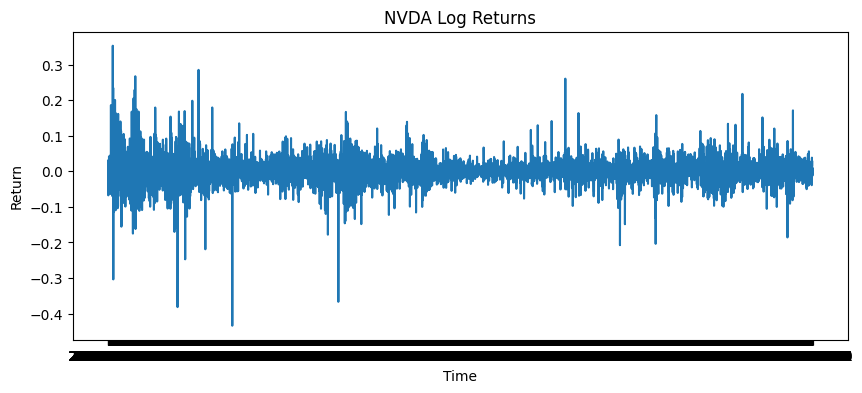

In [9]:
plt.figure(figsize=(10,4))
plt.plot(returns)
plt.title("NVDA Log Returns")
plt.xlabel("Time")
plt.ylabel("Return")
plt.show()

The plot shows the daily log returns of NVDA over the sample period. The Returns fluctuate around zero, which is expected since log returns remove long-term price trends and center the series near their mean.

Importantly, the strength of fluctation varies over time, indicating periods of higher and lower volatility. This suggests the presence of time-varying volatility regimes, which motivates my use of a Hidden Markov Model (HMM). In hopes to capture the underlying distributions governing market behavior.

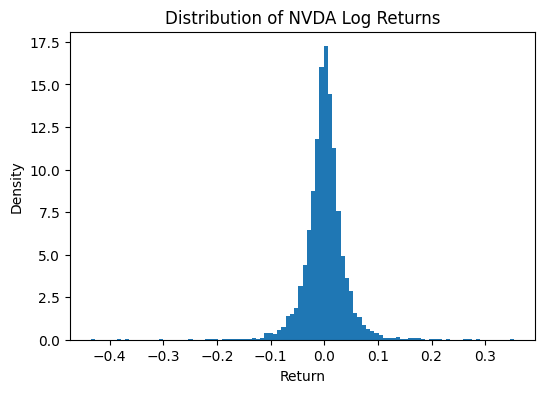

In [10]:
plt.figure(figsize=(6,4))
plt.hist(returns, bins=100, density=True)
plt.title("Distribution of NVDA Log Returns")
plt.xlabel("Return")
plt.ylabel("Density")
plt.show()

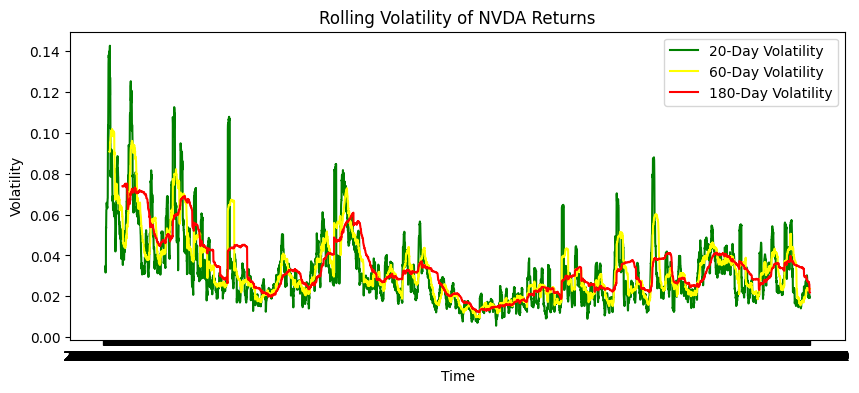

In [11]:
rolling_vol_30 = returns.rolling(20).std()
rolling_vol_50 = returns.rolling(60).std()
rolling_vol_100 = returns.rolling(180).std()

plt.figure(figsize=(10,4))

plt.plot(rolling_vol_30, label="20-Day Volatility", color="green")
plt.plot(rolling_vol_50, label="60-Day Volatility", color="yellow")
plt.plot(rolling_vol_100, label="180-Day Volatility", color="red")

plt.title("Rolling Volatility of NVDA Returns")
plt.xlabel("Time")
plt.ylabel("Volatility")

plt.legend()
plt.show()

Looks cool, could have some cool explanation 

In [12]:
results = []
best_models = {}

for K in range(1,6):

    scores = []
    models = []

    print("\nTesting K =", K)

    for i in range(20):

        ran_state = random.randint(1,10000)

        model = GaussianHMM(
            n_components=K,
            covariance_type="diag",
            n_iter=2000,
            tol=1e-3,
            random_state=ran_state
        )

        model.fit(X)

        score = model.score(X)

        scores.append(score)
        models.append(model)


    best_idx = np.argmax(scores)
    best_model = models[best_idx]
    best_score = scores[best_idx]

    worst_score = min(scores)
    diff = best_score - worst_score

    print("Best score:", best_score)
    print("Worst score:", worst_score)
    print("Difference:", diff)

    best_models[K] = best_model

    results.append({
        "K":K,
        "best_logL":best_score,
        "worst_logL":worst_score,
        "diff":diff
    })


Testing K = 1
Best score: 12264.89304804902
Worst score: 12264.89304804902
Difference: 0.0

Testing K = 2
Best score: 13421.556476554577
Worst score: 13421.555214043752
Difference: 0.0012625108247448225

Testing K = 3


Model is not converging.  Current: 13626.624905348213 is not greater than 13626.626189744118. Delta is -0.0012843959048041143
Model is not converging.  Current: 13626.091634226992 is not greater than 13626.094803123971. Delta is -0.003168896979332203
Model is not converging.  Current: 13627.653768430611 is not greater than 13627.65467667404. Delta is -0.0009082434280571761
Model is not converging.  Current: 13627.535761100298 is not greater than 13627.539719332864. Delta is -0.003958232566219522
Model is not converging.  Current: 13626.120370035225 is not greater than 13626.123365208026. Delta is -0.002995172801092849
Model is not converging.  Current: 13626.08345386833 is not greater than 13626.085700226948. Delta is -0.002246358617412625
Model is not converging.  Current: 13626.094306653056 is not greater than 13626.096209754603. Delta is -0.001903101547213737
Model is not converging.  Current: 13626.036834861485 is not greater than 13626.042700365537. Delta is -0.0058655040520534385

Best score: 13627.64546184722
Worst score: 13626.0255513088
Difference: 1.6199105384202994

Testing K = 4


Model is not converging.  Current: 13699.576440873037 is not greater than 13699.57693472799. Delta is -0.0004938549518556101
Model is not converging.  Current: 13682.17315500146 is not greater than 13682.175514343864. Delta is -0.002359342404815834
Model is not converging.  Current: 13663.045039277173 is not greater than 13663.045513137144. Delta is -0.000473859970952617
Model is not converging.  Current: 13682.166707310478 is not greater than 13682.16677512686. Delta is -6.781638148822822e-05
Model is not converging.  Current: 13682.072300280079 is not greater than 13682.074367035575. Delta is -0.0020667554963438306
Model is not converging.  Current: 13688.362062839087 is not greater than 13688.363429654248. Delta is -0.0013668151605088497
Model is not converging.  Current: 13700.035243607914 is not greater than 13700.037104401636. Delta is -0.0018607937217893777


Best score: 13700.025165477826
Worst score: 13663.043104574903
Difference: 36.98206090292297

Testing K = 5


Model is not converging.  Current: 13760.593122460175 is not greater than 13760.594551741568. Delta is -0.0014292813921201741
Model is not converging.  Current: 13759.78495882505 is not greater than 13759.78639112438. Delta is -0.0014322993301902898


Best score: 13766.573490138513
Worst score: 13688.273546792574
Difference: 78.29994334593903


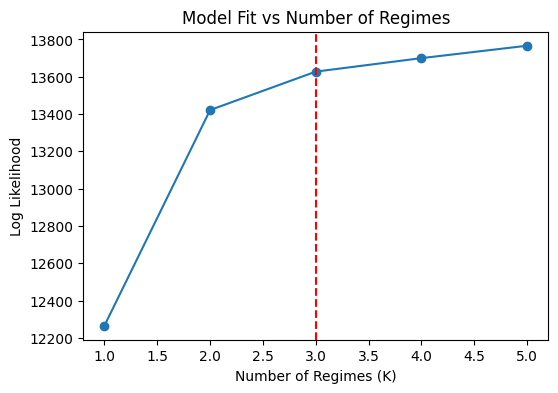

In [13]:
Ks = [r["K"] for r in results]
scores = [r["best_logL"] for r in results]

plt.figure(figsize=(6,4))
plt.plot(Ks, scores, marker="o")
plt.xlabel("Number of Regimes (K)")
plt.ylabel("Log Likelihood")
plt.title("Model Fit vs Number of Regimes")
plt.axvline(x=3, color="red", linestyle="--", label="Chosen K=3")
plt.show()

The plot shows the log-likelihood of the Hidden Markov Model as a function of the number of regimes K. As expected, the log-likelihood increases as additional regimes are introduced, since a more flexible model can better capture more structure in the data.

However, the marginal improvement in log-likelihood begins to diminish after K = 3. The sharp increase from K=1 to K=2 and the continued improvement at K=3 indicate that multiple volatility regimes are present in the return series. Beyond this point, the gains in model fit become relatively small. I believe this suggest that additional regimes primarily capture noise rather than meaningful structure.

The dashed vertical line highlights K=3 as the selected model (# of regimes). 

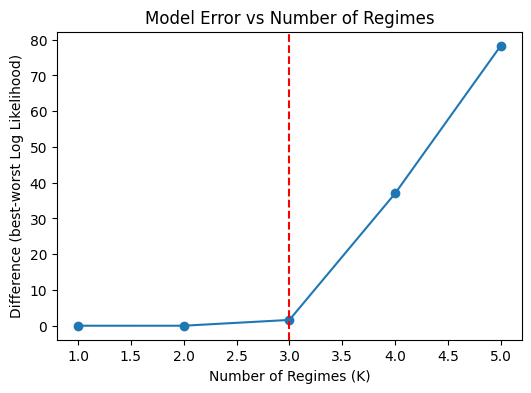

In [14]:
Ks = [r["K"] for r in results]
diff = [r["diff"] for r in results]

plt.figure(figsize=(6,4))
plt.plot(Ks, diff, marker="o")
plt.xlabel("Number of Regimes (K)")
plt.ylabel("Difference (best-worst Log Likelihood)")
plt.title("Model Error vs Number of Regimes")
plt.axvline(x=3, color="red", linestyle="--", label="Chosen K=3")
plt.show()

This visualization shows that K=3 is more than just best fit based on log likehood. But it's also a strong canddidate for the 20 iterations of model fitting that regular agreed on the confident of the log likelhood.

In [15]:
K = 3

model = best_models[K]

print("Final Model Score:", model.score(X))
print("Converged:", model.monitor_.converged)

Final Model Score: 13627.64546184722
Converged: True


Now that we have fit our data on the model with 3 regimes. Hopefully, we may also caputre different techniques to predict and how the prediction looks overall.

In [16]:
transmat = model.transmat_
startprob = model.startprob_
print("Transition Matrix:")
print(transmat)
print("Start Probabilities:")
print(startprob)

Transition Matrix:
[[9.74763659e-01 1.69084598e-03 2.35454952e-02]
 [4.11864520e-08 9.12864200e-01 8.71357588e-02]
 [2.57909178e-02 1.66963493e-02 9.57512733e-01]]
Start Probabilities:
[4.79791885e-87 4.37018786e-27 1.00000000e+00]


In [17]:
mu = model.means_.flatten()
sigma = np.sqrt(model.covars_.flatten())

order = np.argsort(sigma)

labels = ["Low", "Med", "High"]

In [18]:
state_to_regime = {
    state_idx: labels[i]
    for i, state_idx in enumerate(order)
}

state_to_regime

{np.int64(0): 'Low', np.int64(2): 'Med', np.int64(1): 'High'}

In [19]:
states = model.predict(X)

print(states[:10])

[2 2 2 2 2 2 2 2 2 2]


In [20]:
df = pd.DataFrame(
    {
        "ret": returns.values.flatten(),
        "state": states
    },
    index=returns.index
)

df["regime"] = df["state"].map(state_to_regime)

print(state_to_regime)
print(df.head())

{np.int64(0): 'Low', np.int64(2): 'Med', np.int64(1): 'High'}
                 ret  state regime
Date                              
2000-01-04 -0.027064      2    Med
2000-01-05 -0.033476      2    Med
2000-01-06 -0.067479      2    Med
2000-01-07  0.016562      2    Med
2000-01-10  0.032301      2    Med


In [21]:
summary = df.groupby("regime")["ret"].agg(
    mean="mean",
    std="std",
    var="var",
    count="count",
    min="min",
    max="max"
)

print(summary)

            mean       std       var  count       min       max
regime                                                         
High    0.001104  0.092095  0.008482    485 -0.434383  0.353573
Low     0.002232  0.018582  0.000345   2951 -0.076677  0.084527
Med     0.000168  0.035261  0.001243   3102 -0.134145  0.135150


Create a Observation BoxPlot and a Frequency Histrogram

(How my model aligns with events like COVID, 2008, 2022, AI Boom) Or we actaully getting anything out of this model

Heatmap of Persistence since or do a graph visual again (where my diagonal would show persistence)

The expected time between regimes, maybe between all regimes relationship with each other
(Also, how long does it just natural last)

Within certain time period, does persistence seem to overcompensate, causing regime switching to go beyond the typical

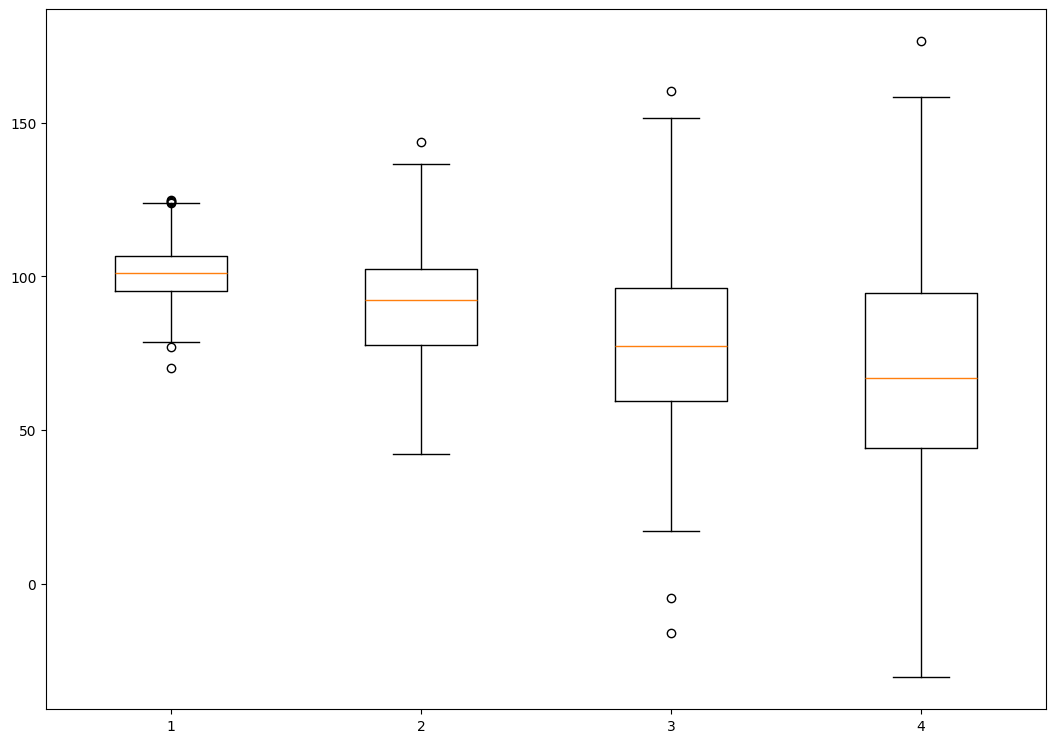

In [22]:
np.random.seed(10)

d_1 = np.random.normal(100, 10, 200)
d_2 = np.random.normal(90, 20, 200)
d_3 = np.random.normal(80, 30, 200)
d_4 = np.random.normal(70, 40, 200)
d = [d_1, d_2, d_3, d_4]

fig = plt.figure(figsize =(10, 7))
ax = fig.add_axes([0, 0, 1, 1])
bp = ax.boxplot(d)

plt.show()

Graph:

#



/var/folders/m3/55vn77px58s9m__ndct5d9w80000gn/T/ipykernel_22456/3845432278.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order)


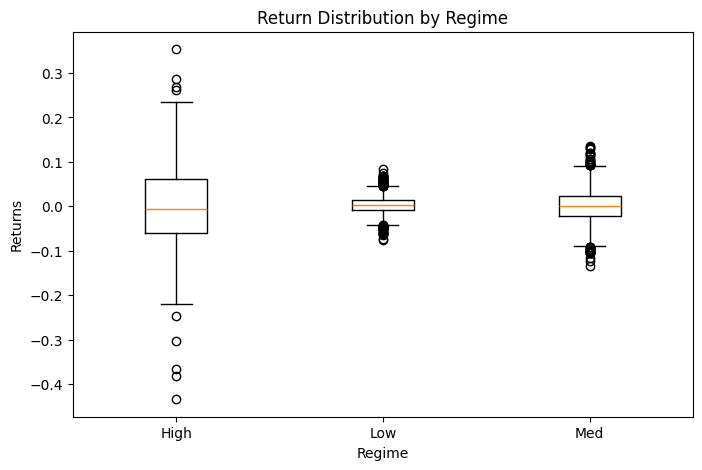

In [24]:
order = sorted(df["regime"].unique())

# Collect data for each regime
data = [df[df["regime"] == r]["ret"] for r in order]

plt.figure(figsize=(8,5))

plt.boxplot(data, labels=order)

plt.title("Return Distribution by Regime")
plt.xlabel("Regime")
plt.ylabel("Returns")

plt.show()